# Testing Small MLPs on the data
In this notebook i am trying out different small models as a sanity check of whether the single-cell-sequencing can be used for the final project.

Content:


In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
import shap
from sklearn.decomposition import PCA

In [4]:
# Load file
FILE_PATH = "../data/Variant_Vax_obj.h5ad"
adata = sc.read_h5ad(FILE_PATH)

##### Expression Matrix
This is the big one.
Shape: cellx x genes
.... chat is saying we shouldn't compress it to a table since it will crash the RAM/memory.

I have a pre-processing step, which i don't think is nessesary. I am unsure if it messes things up if it is already done...

In [5]:
# Pre-process
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# feature selection + pca
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata)
sc.tl.pca(adata, n_comps=50)

/Users/ingridkjaerulffjensen/envs/mlenv/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [6]:
# ML-matrix
X_ml = adata.obsm["X_pca"]

In [8]:
adata.X.max(), adata.X.min()

(184.79092, -1.1692383)

In [9]:
adata.X[:1000].sum() / (1000 * adata.shape[1])

-0.03688695703125

## Small MLP to try and predict COVID status (cell-level split)

In [ ]:
# -----------------------------
# 1. Data
# -----------------------------
X = adata.obsm["X_pca"]
y = adata.obs["SARSCoV2_PCR_Status"]

# encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

print("Classes:", le.classes_)

# -----------------------------
# 2. Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# 3. Torch tensors
# -----------------------------
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# -----------------------------
# 4. Tiny MLP
# -----------------------------
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, len(np.unique(y_enc)))
)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------
# 5. Training
# -----------------------------
for epoch in range(10):
    model.train()

    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

# -----------------------------
# 6. Evaluation
# -----------------------------
model.eval()

with torch.no_grad():
    preds = model(X_test).argmax(dim=1)
    acc = (preds == y_test).float().mean()

print("Test accuracy:", acc.item())

Classes: ['negative' 'positive']
Epoch 1 | Loss: 0.7369
Epoch 2 | Loss: 0.7177
Epoch 3 | Loss: 0.6994
Epoch 4 | Loss: 0.6819
Epoch 5 | Loss: 0.6653
Epoch 6 | Loss: 0.6495
Epoch 7 | Loss: 0.6346
Epoch 8 | Loss: 0.6205
Epoch 9 | Loss: 0.6072
Epoch 10 | Loss: 0.5947
Test accuracy: 0.7378411889076233


As input features, we used a PCA-reduced representation (adata.obsm["X_pca"]), where the original gene expression matrix was compressed into ~50 principal components per cell. The full gene expression table itself was not used directly for machine learning due to its high dimensionality. The prediction target was SARSCoV2_PCR_Status, a binary label indicating COVID-19 positive or negative status for each cell. Labels were encoded into integers and the dataset was split into 80% training and 20% test cells using stratified sampling. A small feedforward neural network with one hidden layer (32 units) was trained for 10 epochs using cross-entropy loss. The model achieved a test accuracy of approximately 0.79, outperforming a majority-class baseline. This indicates that infection status is strongly reflected in the low-dimensional transcriptional structure captured by PCA.

## COVID status MLP (slightly larger model) + Patient-level split
Here i am splitting on cell-level (not patient level). This is wrong since it creates data-leakage. I'm keeping it in the notebook for illustrative purposes. Further down I am splitting on a patient-level and we see a 10% drop in test-accuracy, demonstrating the data leakage from splitting on a cell-level-

In [ ]:
print("Small MLP, split on cellular level (data leakage)")
# -----------------------------
# 1. Data
# -----------------------------
X = adata.obsm["X_pca"]
y = adata.obs["SARSCoV2_PCR_Status"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

# -----------------------------
# 2. Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# 3. Torch tensors
# -----------------------------
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# -----------------------------
# 4. Slightly bigger MLP
# -----------------------------
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, len(np.unique(y_enc)))
)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------
# 5. Training
# -----------------------------
for epoch in range(10):
    model.train()

    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

# -----------------------------
# 6. Evaluation
# -----------------------------
model.eval()

with torch.no_grad():
    preds = model(X_test).argmax(dim=1)
    acc = (preds == y_test).float().mean()

print("Test accuracy:", acc.item())

Epoch 1 | Loss: 0.6381
Epoch 2 | Loss: 0.6156
Epoch 3 | Loss: 0.5935


Epoch 4 | Loss: 0.5724
Epoch 5 | Loss: 0.5527
Epoch 6 | Loss: 0.5347
Epoch 7 | Loss: 0.5187
Epoch 8 | Loss: 0.5051
Epoch 9 | Loss: 0.4939
Epoch 10 | Loss: 0.4852
Test accuracy: 0.8001231551170349


## Splitting on Patient-level (same model as above)
We are still predicting COVID-status (positive/negative)

In [ ]:
print("Patient-level split: ")
# -----------------------------
# 1. Features + labels
# -----------------------------
X = adata.obsm["X_pca"]
y = adata.obs["SARSCoV2_PCR_Status"].values
participants = adata.obs["Participant"].values

# encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

# -----------------------------
# 2. Split by PARTICIPANT - data points are still individual cells
# -----------------------------
unique_participants = np.unique(participants)

train_participants, test_participants = train_test_split(
    unique_participants,
    test_size=0.2,
    random_state=42
)

# masks
train_mask = np.isin(participants, train_participants)
test_mask = np.isin(participants, test_participants)

# apply masks
X_train = X[train_mask]
X_test = X[test_mask]

y_train = y_enc[train_mask]
y_test = y_enc[test_mask]

# -----------------------------
# 3. Torch tensors
# -----------------------------
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# -----------------------------
# 4. MLP
# -----------------------------
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, len(np.unique(y_enc)))
)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------
# 5. Training
# -----------------------------
for epoch in range(10):
    model.train()

    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

# -----------------------------
# 6. Evaluation
# -----------------------------
model.eval()

with torch.no_grad():
    preds = model(X_test).argmax(dim=1)
    acc = (preds == y_test).float().mean()

print("Test accuracy:", acc.item())

Epoch 1 | Loss: 0.8016
Epoch 2 | Loss: 0.7554
Epoch 3 | Loss: 0.7175
Epoch 4 | Loss: 0.6860
Epoch 5 | Loss: 0.6588
Epoch 6 | Loss: 0.6342
Epoch 7 | Loss: 0.6114
Epoch 8 | Loss: 0.5899
Epoch 9 | Loss: 0.5692
Epoch 10 | Loss: 0.5494
Test accuracy: 0.706292986869812


Trying yet another larger model...:

In [ ]:
# -----------------------------
# 1. Data
# -----------------------------
X = adata.obsm["X_pca"]
y = adata.obs["SARSCoV2_PCR_Status"].values
patients = adata.obs["Participant"].values

le = LabelEncoder()
y_enc = le.fit_transform(y)

# -----------------------------
# 2. PATIENT-LEVEL SPLIT
# -----------------------------
unique_patients = np.unique(patients)

train_patients, test_patients = train_test_split(
    unique_patients,
    test_size=0.2,
    random_state=42
)

train_mask = np.isin(patients, train_patients)
test_mask = np.isin(patients, test_patients)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y_enc[train_mask], y_enc[test_mask]

# -----------------------------
# 3. Torch tensors
# -----------------------------
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# -----------------------------
# 4. Bigger MLP (unchanged)
# -----------------------------
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, len(np.unique(y_enc)))
)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------
# 5. Training
# -----------------------------
for epoch in range(10):
    model.train()

    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

# -----------------------------
# 6. Evaluation
# -----------------------------
model.eval()

with torch.no_grad():
    preds = model(X_test).argmax(dim=1)
    acc = (preds == y_test).float().mean()

print("Test accuracy:", acc.item())

Epoch 1 | Loss: 0.6925
Epoch 2 | Loss: 0.6546
Epoch 3 | Loss: 0.6129
Epoch 4 | Loss: 0.5707
Epoch 5 | Loss: 0.5304
Epoch 6 | Loss: 0.4953
Epoch 7 | Loss: 0.4688
Epoch 8 | Loss: 0.4533
Epoch 9 | Loss: 0.4488
Epoch 10 | Loss: 0.4520
Test accuracy: 0.706292986869812


## Permutation Importance for feature importance on PC's
Attempting to see which PCA-component matters the most for prediction.

In [ ]:
# use trained model
model.eval()

# baseline accuracy
with torch.no_grad():
    base_preds = model(X_test).argmax(dim=1)
    base_acc = (base_preds == y_test).float().mean().item()

print("Baseline accuracy:", base_acc)

# number of PCA features
n_features = X_test.shape[1]

importances = np.zeros(n_features)

# permutation importance (fast version)
for i in range(n_features):
    X_perm = X_test.clone()

    # shuffle one feature
    idx = torch.randperm(X_perm.shape[0])
    X_perm[:, i] = X_perm[idx, i]

    with torch.no_grad():
        preds = model(X_perm).argmax(dim=1)
        acc = (preds == y_test).float().mean().item()

    importances[i] = base_acc - acc

# sort
top_idx = np.argsort(importances)[::-1]

print("\nTop 10 PCA features:")
for i in top_idx[:10]:
    print(f"PC{i}: importance={importances[i]:.4f}")

Baseline accuracy: 0.8001231551170349

Top 10 PCA features:
PC49: importance=0.0000
PC12: importance=0.0000
PC22: importance=0.0000
PC21: importance=0.0000
PC20: importance=0.0000
PC19: importance=0.0000
PC18: importance=0.0000
PC17: importance=0.0000
PC16: importance=0.0000
PC15: importance=0.0000


This result shows zero for all the PC's:
The model is likely (according to LLM):
- spreading information across many PCs
- OR barely using the PCs meaningfully
- OR your accuracy metric is too coarse to detect small changes

Also, since our data set is small, the accuracy might change more so in discrete jumps.

Conclusion: PCA-level importance is too abstract.

## Trying SHAP...

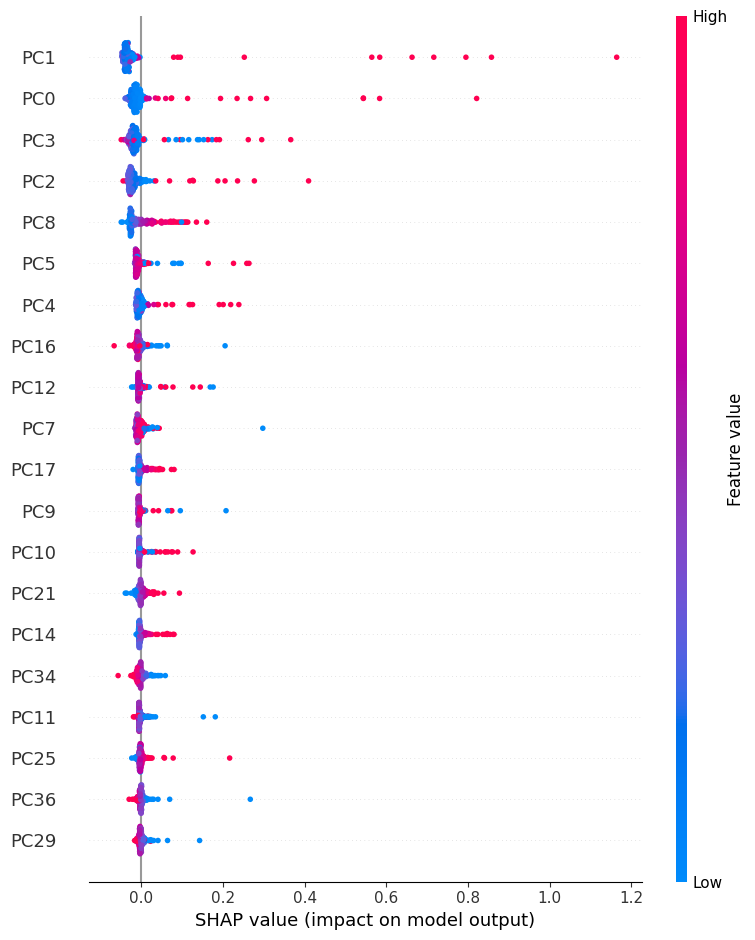

In [ ]:
# -----------------------------
# 1. Use smaller subsets
# -----------------------------
background = X_train[:200]
test_samples = X_test[:200]

# -----------------------------
# 2. SHAP explainer
# -----------------------------
explainer = shap.DeepExplainer(model, background)

# -----------------------------
# 3. Compute SHAP values
# -----------------------------
shap_values = explainer.shap_values(test_samples)

# binary classification:
# use positive class explanations
sv = shap_values[1]

# convert tensors if needed
if hasattr(test_samples, "numpy"):
    X_plot = test_samples.numpy()
else:
    X_plot = test_samples

# -----------------------------
# 4. Summary plot
# -----------------------------
feature_names = [f"PC{i}" for i in range(X_plot.shape[1])]

shap.summary_plot(
    sv,
    X_plot,
    feature_names=feature_names
)

SHAP shows similar tendency as permutation importance

# Expression-only pipeline (Secretory cells pseudobulk)
But Maryam already did this way better and nicer, so don't mind it!

In [ ]:
# -----------------------------
# 1. Filter to Secretory cells ONLY
# -----------------------------
adata_sub = adata[
    adata.obs["Coarse_Annotation"] == "Secretory"
].copy()

# -----------------------------
# 2. Pseudobulk: patient × genes
# -----------------------------
expr = pd.DataFrame(
    adata_sub.X.toarray() if hasattr(adata_sub.X, "toarray") else adata_sub.X,
    index=adata_sub.obs["Participant"],
    columns=adata_sub.var_names
)

pseudobulk = expr.groupby(expr.index).mean()

# -----------------------------
# 3. Attach patient labels (severity / status)
# -----------------------------
labels = (
    adata.obs[["Participant", "SARSCoV2_PCR_Status"]]
    .drop_duplicates()
    .set_index("Participant")
)

data = pseudobulk.join(labels).dropna()

X = data.drop(columns=["SARSCoV2_PCR_Status"]).values
y = data["SARSCoV2_PCR_Status"].values

# encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

# -----------------------------
# 4. Train/test split (PATIENT LEVEL already ensured)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# 5. Normalize (log1p)
# -----------------------------
X_train = np.log1p(X_train)
X_test = np.log1p(X_test)

# -----------------------------
# 6. PCA (fit ONLY on train)
# -----------------------------
pca = PCA(n_components=50)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# -----------------------------
# 7. Torch tensors
# -----------------------------
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# -----------------------------
# 8. Small MLP (fast + stable)
# -----------------------------
model = nn.Sequential(
    nn.Linear(50, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, len(np.unique(y_enc)))
)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------
# 9. Training
# -----------------------------
for epoch in range(10):
    model.train()

    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

# -----------------------------
# 10. Evaluation
# -----------------------------
model.eval()

with torch.no_grad():
    preds = model(X_test).argmax(dim=1)
    acc = (preds == y_test).float().mean()

print("Test accuracy:", acc.item())

Epoch 1 | Loss: 0.6946
Epoch 2 | Loss: 0.6804
Epoch 3 | Loss: 0.6665
Epoch 4 | Loss: 0.6530
Epoch 5 | Loss: 0.6398
Epoch 6 | Loss: 0.6268
Epoch 7 | Loss: 0.6139
Epoch 8 | Loss: 0.6012
Epoch 9 | Loss: 0.5886
Epoch 10 | Loss: 0.5760
Test accuracy: 0.8695651888847351


I took Secretory cells and turned them into a patient-level dataset by averaging gene expression across all Secretory cells per patient (pseudobulk). This produced one row per patient with gene expression values specific to that cell type. I then split patients into train and test groups, applied log transformation and PCA to compress the gene space, and trained a small neural network to predict COVID status using only these expression patterns.

The model reached ~0.87 accuracy on unseen patients, meaning Secretory cell gene expression alone carries a strong signal about infection status. This suggests that within-cell-type transcriptional changes are highly informative, potentially even more than cell composition in this dataset. However, this still needs to be validated across other cell types and compared directly to the composition-based model.

## Same but for Ciliated cells

In [ ]:
# -----------------------------
# 1. Filter to Ciliated cells
# -----------------------------
adata_sub = adata[
    adata.obs["Coarse_Annotation"] == "Ciliated"
].copy()

# -----------------------------
# 2. Remove patients with too few cells
# -----------------------------
cell_counts = adata_sub.obs["Participant"].value_counts()
valid_patients = cell_counts[cell_counts > 5].index

adata_sub = adata_sub[
    adata_sub.obs["Participant"].isin(valid_patients)
].copy()

# -----------------------------
# 3. Pseudobulk: patient × genes
# -----------------------------
expr = pd.DataFrame(
    adata_sub.X.toarray() if hasattr(adata_sub.X, "toarray") else adata_sub.X,
    index=adata_sub.obs["Participant"],
    columns=adata_sub.var_names
)

pseudobulk = expr.groupby(expr.index).mean()

# -----------------------------
# 4. Attach labels (safe inner join)
# -----------------------------
labels = (
    adata.obs[["Participant", "SARSCoV2_PCR_Status"]]
    .drop_duplicates()
    .set_index("Participant")
)

data = pseudobulk.join(labels, how="inner").dropna()

# -----------------------------
# 5. Features + labels
# -----------------------------
X = data.drop(columns=["SARSCoV2_PCR_Status"]).values
y = data["SARSCoV2_PCR_Status"].values

le = LabelEncoder()
y_enc = le.fit_transform(y)

# -----------------------------
# 6. Train/test split (patient-level already guaranteed)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# 7. Log transform
# -----------------------------
X_train = np.log1p(X_train)
X_test = np.log1p(X_test)

# -----------------------------
# 8. PCA (fit on train only)
# -----------------------------
pca = PCA(n_components=50)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# -----------------------------
# 9. Torch tensors
# -----------------------------
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# -----------------------------
# 10. Small MLP
# -----------------------------
model = nn.Sequential(
    nn.Linear(50, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, len(np.unique(y_enc)))
)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------
# 11. Training
# -----------------------------
for epoch in range(10):
    model.train()

    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

# -----------------------------
# 12. Evaluation
# -----------------------------
model.eval()

with torch.no_grad():
    preds = model(X_test).argmax(dim=1)
    acc = (preds == y_test).float().mean()

print("Test accuracy (Ciliated):", acc.item())

Epoch 1 | Loss: 0.6737
Epoch 2 | Loss: 0.6662
Epoch 3 | Loss: 0.6588
Epoch 4 | Loss: 0.6516
Epoch 5 | Loss: 0.6446
Epoch 6 | Loss: 0.6377
Epoch 7 | Loss: 0.6309
Epoch 8 | Loss: 0.6241
Epoch 9 | Loss: 0.6174
Epoch 10 | Loss: 0.6106
Test accuracy (Ciliated): 0.75
